In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path="/content/drive/MyDrive/audiodatasets"

In [ ]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import sklearn.metrics as skm
import sklearn.model_selection as skms
import sklearn.preprocessing as skp
import random, os
import librosa, IPython
import librosa.display as lplt
from skimage.io import imread
seed = 12
np.random.seed(seed)

In [ ]:
trainPath = '/content/drive/MyDrive/audiodatasets/TRAIN'
testPath = '/content/drive/MyDrive/audiodatasets/TEST'
df_base = pd.read_csv('/content/drive/MyDrive/audiodatasets/TRAIN.csv')
df_base.head()

,Filename,Class
0,346.wav,Negative
1,163.wav,Neutral
2,288.wav,Negative
3,279.wav,Negative
4,244.wav,Negative


In [ ]:
print("Dataset has",df_base.shape[0],"samples")
print("Count of Positive and Negative samples")
df_base['Class'].value_counts().reset_index()

Dataset has 250 samples
Count of Positive and Negative samples


,Class,count
0,Negative,87
1,Positive,82
2,Neutral,81


In [ ]:
sample_rate = 44100
def loadAudio(fp):
    return librosa.load(fp, res_type='kaiser_fast', duration=2.5, offset=0.5, sr=sample_rate)

In [ ]:
def scanFeatures(path, avgFeat=0):
    features = []
    minFeat = sys.maxsize
    maxFeat = 0
    files = sorted(os.listdir(path))
    print("Scanning", path)

    for i, fp in enumerate(files):
        X, sr = loadAudio(os.path.join(path, fp))

        f = librosa.feature.melspectrogram(y=X, sr=sample_rate)
        f = librosa.amplitude_to_db(f, ref=np.max)

        shapeY = f.shape[1]
        if shapeY < minFeat:
            minFeat = shapeY

        if shapeY > maxFeat:
            maxFeat = shapeY

        features.append(f)
    if avgFeat == 0:
        avgFeat = int((minFeat+maxFeat)/2)
    feat_mat = np.zeros((len(files), f.shape[0], avgFeat))
    for i, x in enumerate(features):
        xWidth = min(x.shape[1],avgFeat)
        feat_mat[i, :, :xWidth] = x[:,:xWidth]
    return feat_mat, files

In [ ]:
!pip uninstall -y resampy  # Uninstall resampy if it's installed already
!pip install resampy  # Re-install to make sure it's the latest version
!pip install --upgrade librosa # Upgrade librosa in case it uses lazy loading
import resampy  # Force loading resampy first
import librosa  # Then import librosa
f_dim = 128
train_data, train_files = scanFeatures(trainPath, f_dim)
test_data, test_files = scanFeatures(testPath, train_data.shape[1])
print(train_data.shape)
print(test_data.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.7 MB/s eta 0:00:00
Scanning /content/drive/MyDrive/audiodatasets/TRAIN
Scanning /content/drive/MyDrive/audiodatasets/TEST
(250, 128, 128)
(110, 128, 128)


In [ ]:
def saveImg(f, fp):
    f = np.flip(f, axis=0)
    plt.figure()
    plt.axis('off')
    plt.imsave(fp, f, format='png')
    plt.clf()

In [ ]:
def saveFeatureToImage(path, saveDir, avgFeat=0):
    global sample_rate
    files = sorted(os.listdir(path))
    print("Scanning", path)

    for i, fp in enumerate(files):
        X, sr = loadAudio(os.path.join(path, fp))

        f = librosa.feature.melspectrogram(y=X, sr=sample_rate)
        f = librosa.amplitude_to_db(f, ref=np.max)

        img = np.zeros((f.shape[0], avgFeat))
        xWidth = min(f.shape[1],avgFeat)
        img[:, :xWidth] = f[:,:xWidth]
        fname = os.path.join(saveDir, fp.split('.')[0] + '.png')
        saveImg(img, fname)

In [ ]:
f_dim = 128
train_img_dir = './train_images'
test_img_dir = './test_images'
if not os.path.exists(train_img_dir):
    os.mkdir(train_img_dir)
    saveFeatureToImage(trainPath, train_img_dir, f_dim)
if not os.path.exists(test_img_dir):
    os.mkdir(test_img_dir)
    saveFeatureToImage(testPath, test_img_dir, train_data.shape[1])

Scanning /content/drive/MyDrive/audiodatasets/TRAIN
Scanning /content/drive/MyDrive/audiodatasets/TEST


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
def scanImgFeatures(path):
    features = []
    files = sorted(os.listdir(path))
    for x in files:
        fp = os.path.join(path, x)
        img = imread(fp)[:,:,:3]/255.0
        features.append(img)
    return np.array(features), files

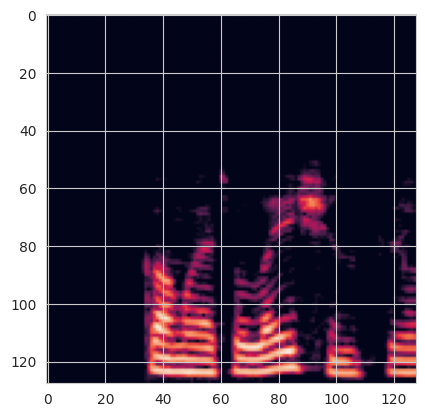

In [ ]:
if os.path.exists(train_img_dir):
    train_data_img, train_files_img = scanImgFeatures(train_img_dir)
if os.path.exists(test_img_dir):
    test_data_img, test_files_img = scanImgFeatures(test_img_dir)
    plt.imshow(test_data_img[0])
    plt.show()

In [ ]:
def getPathLabels(p):
    return [df_base[df_base['Filename'] == x].iloc[0,1] for x in p]

In [ ]:
train_labels = getPathLabels(train_files)

In [ ]:
audio_fp = '/content/drive/MyDrive/audiodatasets/TEST/7.wav'
audio_data, sr = loadAudio(audio_fp)
audio_data, _ = librosa.effects.trim(audio_data)

In [ ]:
IPython.display.Audio(audio_data, rate=sr)

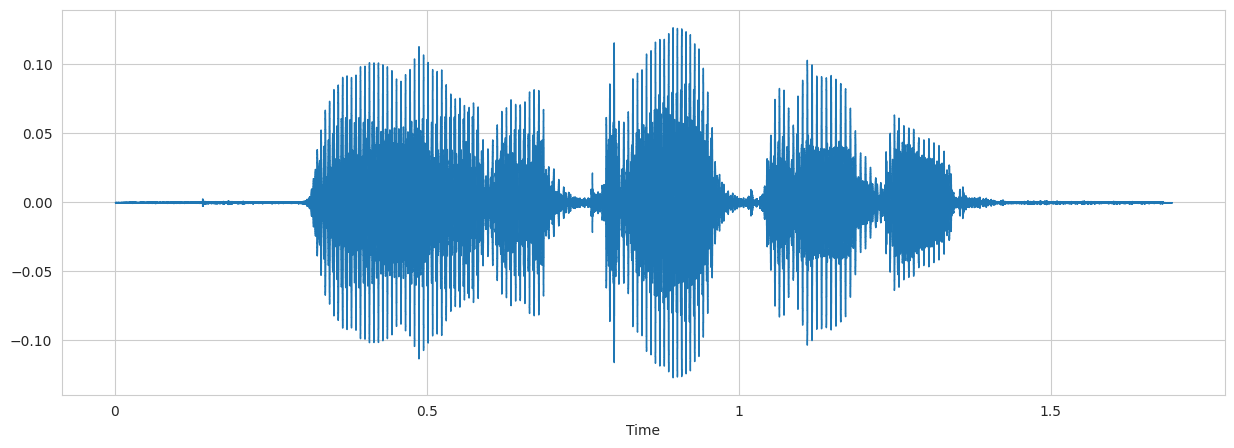

In [ ]:
plt.figure(figsize=(15,5))
# lplt.waveplot(audio_data) # waveplot is deprecated
lplt.waveshow(audio_data, sr=sr) # Use waveshow instead
plt.show()

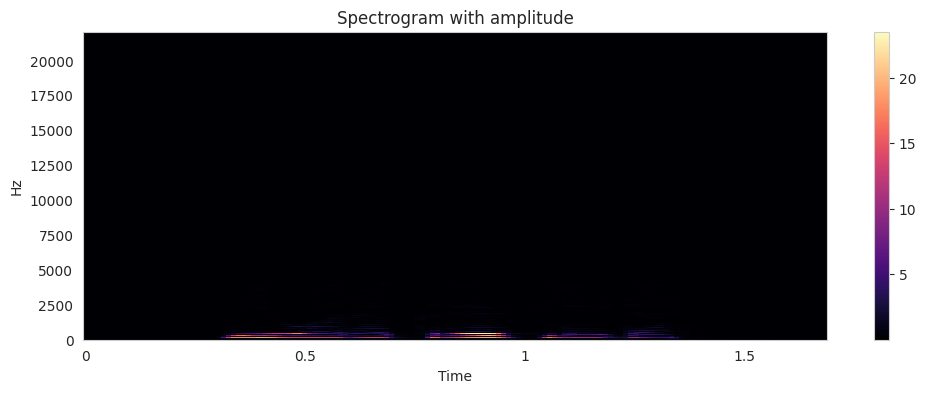

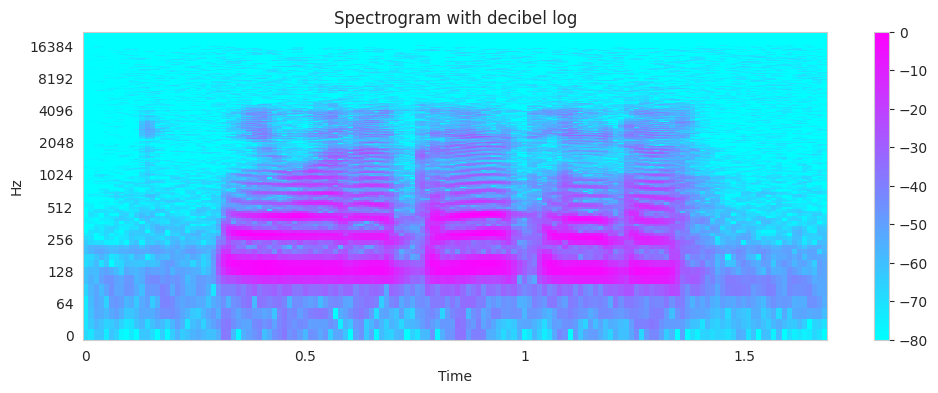

In [ ]:
n_fft = 2048 # window size
hop_length = 512 # window hop length for STFT

stft = librosa.stft(audio_data, n_fft=n_fft, hop_length=hop_length)
stft_db = librosa.amplitude_to_db(stft, ref=np.max)

plt.figure(figsize=(12,4))
lplt.specshow(stft, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram with amplitude")
plt.show()

plt.figure(figsize=(12,4))
lplt.specshow(stft_db, sr=sr, x_axis='time', y_axis='log', cmap='cool')
plt.colorbar()
plt.title("Spectrogram with decibel log")
plt.show()

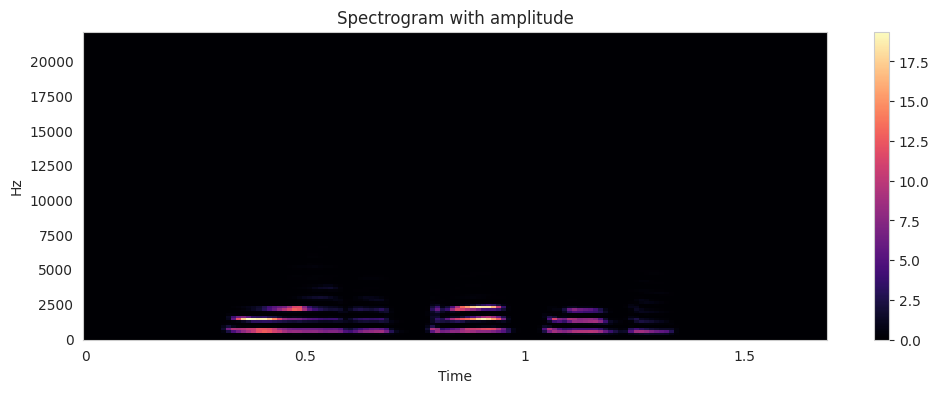

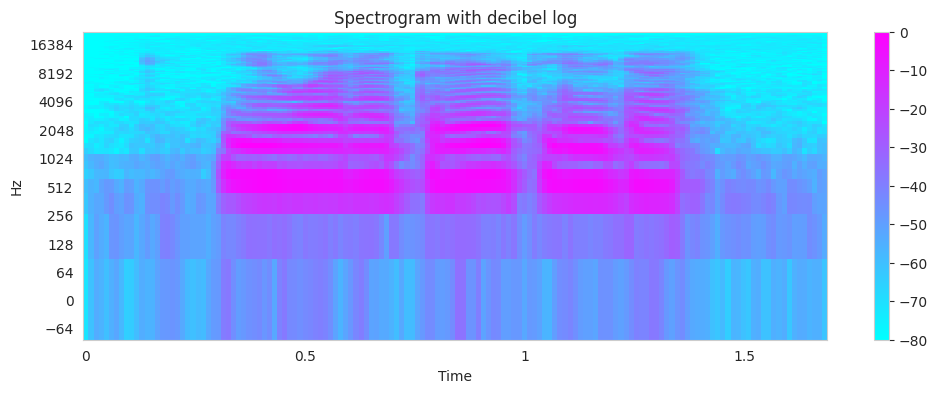

In [ ]:
melspec = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate)
melspec_db = librosa.power_to_db(melspec, ref=np.max)

plt.figure(figsize=(12,4))
librosa.display.specshow(melspec, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram with amplitude")
plt.show()

plt.figure(figsize=(12,4))
librosa.display.specshow(melspec_db, sr=sr, x_axis='time', y_axis='log', cmap='cool')
plt.colorbar()
plt.title("Spectrogram with decibel log")
plt.show()

In [ ]:
label_index = dict()
index_label = dict()
for i, x in enumerate(df_base['Class'].unique()):
    label_index[x] = i
    index_label[i] = x
print(label_index)
print(index_label)

{'Negative': 0, 'Neutral': 1, 'Positive': 2}
{0: 'Negative', 1: 'Neutral', 2: 'Positive'}


In [ ]:
train_labels_idx = [label_index[l] for l in train_labels]
train_labels_idx[::10]

[2, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 2]

In [ ]:
df_shuffle = df_base.sample(frac=1, random_state=seed).reset_index(drop=True)

In [ ]:
df_shuffle.drop(['Filename'], axis=1, inplace=True)
df_y = df_shuffle.pop('Class')

# split into train dev and test
y_train, y_test = skms.train_test_split(df_y, train_size=0.8, random_state=seed, stratify=df_y)

In [ ]:
print(f"Train set has {y_train.shape[0]} records out of {len(df_shuffle)} which is {round(y_train.shape[0]/len(df_shuffle)*100)}%")
print(f"Test set has {y_test.shape[0]} records out of {len(df_shuffle)} which is {round(y_test.shape[0]/len(df_shuffle)*100)}%")

Train set has 200 records out of 250 which is 80%
Test set has 50 records out of 250 which is 20%


In [ ]:
print(y_train.value_counts())
print(y_test.value_counts())

Class
Negative    69
Positive    66
Neutral     65
Name: count, dtype: int64
Class
Negative    18
Neutral     16
Positive    16
Name: count, dtype: int64


In [ ]:
X_train = train_data[y_train.index.tolist(), :, :]
X_test = train_data[y_test.index.tolist(), :, :]
X_test.shape

(50, 128, 128)

In [ ]:
X_train_img = train_data_img[y_train.index.tolist(), :, :]
X_test_img = train_data_img[y_test.index.tolist(), :, :]
X_test_img.shape

(50, 128, 128, 3)

In [ ]:
y_train = np.array([train_labels_idx[x] for x in y_train.index.tolist()])
y_test = np.array([train_labels_idx[x] for x in y_test.index.tolist()])
y_train[::10]

array([1, 2, 2, 2, 2, 0, 2, 0, 1, 1, 1, 1, 2, 0, 0, 2, 1, 0, 0, 2])

In [ ]:
scaler = skp.MinMaxScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
test_data = scaler.transform(test_data.reshape(-1, test_data.shape[-1])).reshape(test_data.shape)
print(X_train.shape)

(200, 128, 128)


In [ ]:
import tensorflow as tf
print("TF version:-", tf.__version__)
import keras as k
from keras import backend as K
tf.random.set_seed(seed)

TF version:- 2.18.0


In [ ]:
!pip install pydub
!apt-get install ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [ ]:
!pip install numpy pandas librosa tensorflow scikit-learn pydub matplotlib
!sudo apt-get install ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [ ]:
from google.colab import drive
import os
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder



# Define paths
BASE_PATH = "/content/drive/MyDrive/audiodatasets/"  # Change if needed
TRAIN_PATH = os.path.join(BASE_PATH, "TRAIN")  # Audio files
TEST_PATH = os.path.join(BASE_PATH, "TEST")  # Test audio files
CSV_PATH = os.path.join(BASE_PATH, "TRAIN.csv")  # CSV file with labels

# Load CSV file
df = pd.read_csv(CSV_PATH)

# Function to extract MFCC features
def extract_features(file_path, max_pad_len=100):
    try:
        audio, sample_rate = librosa.load(file_path, sr=22050)
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        pad_width = max_pad_len - mfccs.shape[1]
        if pad_width > 0:
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]
        return mfccs
    except Exception as e:
        print(f"Error extracting features from {file_path}: {e}")
        return None

# Extract features and labels
X, Y = [], []

for _, row in df.iterrows():
    # Accessing the correct column name "Filename"
    file_name, label = row["Filename"], row["Class"]
    file_path = os.path.join(TRAIN_PATH, file_name)
    features = extract_features(file_path)
    if features is not None:
        X.append(features)
        Y.append(label)

# Convert to numpy arrays
X = np.array(X)
Y = np.array(Y)

# Encode labels
encoder = LabelEncoder()
Y_encoded = encoder.fit_transform(Y)
Y_one_hot = to_categorical(Y_encoded)

# Train-test split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y_one_hot, test_size=0.2, random_state=42)

# Reshape input for LSTM (samples, time-steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[2], X_train.shape[1])
X_val = X_val.reshape(X_val.shape[0], X_val.shape[2], X_val.shape[1])

# Build LSTM Model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(Y_one_hot.shape[1], activation='softmax')
])

# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_data=(X_val, Y_val))

# Save model
model.save("/content/drive/MyDrive/audio_sentiment_model.keras")

# Function to predict sentiment from test audio file
def predict_sentiment(file_name):
    file_path = os.path.join(TEST_PATH, file_name)
    features = extract_features(file_path)
    if features is None:
        return "Error extracting features"
    features = np.expand_dims(features, axis=0)  # Add batch dimension
    features = features.reshape(features.shape[0], features.shape[2], features.shape[1])
    prediction = model.predict(features)
    sentiment_label = encoder.inverse_transform([np.argmax(prediction)])[0]
    return sentiment_label


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 808ms/step - accuracy: 0.3736 - loss: 1.1045 - val_accuracy: 0.3800 - val_loss: 1.0774
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 335ms/step - accuracy: 0.5823 - loss: 1.0039 - val_accuracy: 0.4800 - val_loss: 1.0305
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.5538 - loss: 0.9015 - val_accuracy: 0.4600 - val_loss: 0.9352
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step - accuracy: 0.6099 - loss: 0.8385 - val_accuracy: 0.5000 - val_loss: 0.9248
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - accuracy: 0.7345 - loss: 0.7468 - val_accuracy: 0.7600 - val_loss: 0.7376
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.8357 - loss: 0.5419 - val_accuracy: 0.7800 - val_loss: 0.6509
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 323ms/step - accuracy: 0.8602 - loss: 0.4100 - val_accuracy: 0.7000 - val_loss: 0.5813
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 274ms/step - accuracy: 0.9314 - loss: 0.2823 - val_accuracy: 0.7400 - val_loss

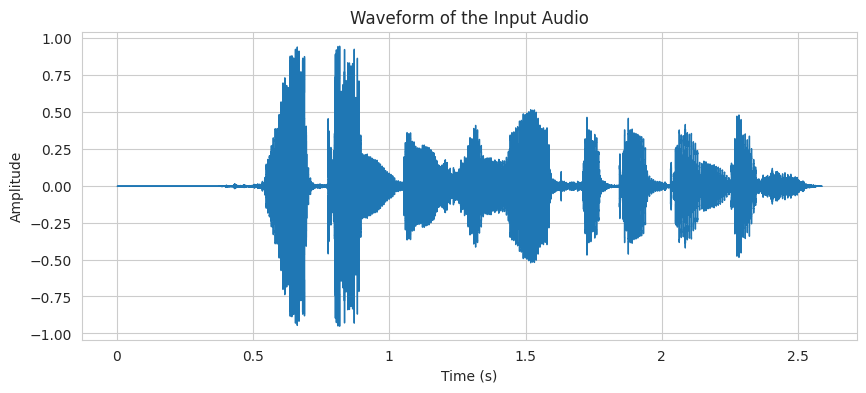

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
Predicted Sentiment: Neutral


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio

# Load the audio file
file_path = "/content/drive/MyDrive/audiodatasets/TRAIN/163.wav"  # Change this to your file path
audio, sr = librosa.load(file_path, sr=None)

# Plot the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Waveform of the Input Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Play the audio
display(Audio(file_path))

# Example: Predict sentiment for a test audio file
  # Replace with an actual file from test/
predicted_sentiment = predict_sentiment(file_path)
print(f"Predicted Sentiment: {predicted_sentiment}")



In [ ]:
def predict_test_files():
    # Get all test .wav files
    test_files = sorted([f for f in os.listdir(TEST_AUDIO_PATH) if f.endswith(".wav")])

    if len(test_files) == 0:
        print(f"🚨 Error: No test files found in {TEST_AUDIO_PATH}. Ensure you have test audio files.")
        return

    # Predict Sentiment for Each File
    predictions = []
    for file_name in test_files:
        file_path = os.path.join(TEST_AUDIO_PATH, file_name)
        predicted_label = predict_audio_sentiment(file_path)
        predictions.append(predicted_label)

    # Create DataFrame with Predictions
    df = pd.DataFrame({"Filename": test_files, "Class": predictions})

    # ✅ Ensure submission.csv is created correctly
    if not df.empty:
        df.to_csv(SUBMISSION_FILE, index=False)
        print(f"✅ Saved predictions to {SUBMISSION_FILE}")
    else:
        print("🚨 Error: No predictions generated. Check the test files.")

    # Print First Few Rows to Confirm
    print(df.head())

In [ ]:
SUBMISSION_FILE= 'submission.csv'
df.to_csv(SUBMISSION_FILE, index=False)
print(f"Submission file saved: {SUBMISSION_FILE}")

Submission file saved: submission.csv


In [ ]:
df = pd.read_csv('submission.csv')
print(df)

    Filename     Class
0    346.wav  Negative
1    163.wav   Neutral
2    288.wav  Negative
3    279.wav  Negative
4    244.wav  Negative
..       ...       ...
245  204.wav   Neutral
246   46.wav  Positive
247  318.wav  Negative
248   49.wav  Positive
249  191.wav   Neutral

[250 rows x 2 columns]


In [ ]:
pip install SpeechRecognition

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 33.7 MB/s eta 0:00:00


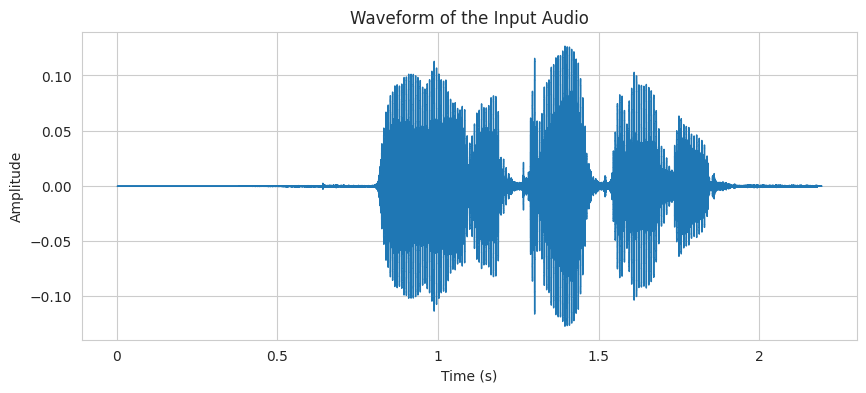

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Transcribed Text: you are a great leader


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


Predicted Sentiment: POSITIVE (Confidence: 1.00)


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
import speech_recognition as sr
from IPython.display import Audio
from transformers import pipeline

# Load the audio file
file_path = "/content/drive/MyDrive/audiodatasets/TEST/7.wav"
audio, sample_rate = librosa.load(file_path, sr=None)

# Plot the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sample_rate)
plt.title("Waveform of the Input Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Play the audio
display(Audio(file_path))

# Convert to PCM WAV format
wav_path = "/content/converted_audio.wav"
sf.write(wav_path, audio, sample_rate, subtype='PCM_16')

# Convert speech to text
recognizer = sr.Recognizer()
with sr.AudioFile(wav_path) as source:
    audio_data = recognizer.record(source)

try:
    transcribed_text = recognizer.recognize_google(audio_data)
    print(f"Transcribed Text: {transcribed_text}")
except sr.UnknownValueError:
    transcribed_text = "[Could not understand the audio]"
except sr.RequestError:
    transcribed_text = "[Speech Recognition service error]"

# Use Hugging Face's sentiment analysis pipeline
if not transcribed_text.startswith("["):
    sentiment_analyzer = pipeline("sentiment-analysis")
    sentiment_result = sentiment_analyzer(transcribed_text)[0]
    predicted_sentiment = f"{sentiment_result['label']} (Confidence: {sentiment_result['score']:.2f})"
else:
    predicted_sentiment = "[Sentiment could not be determined]"

print(f"Predicted Sentiment: {predicted_sentiment}")


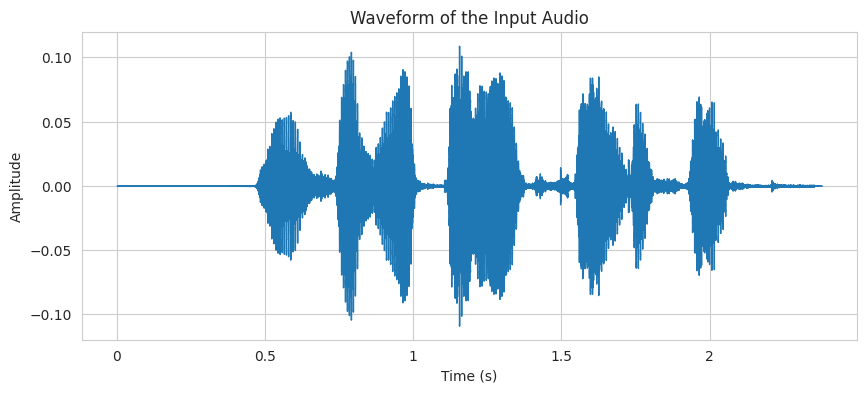

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Transcribed Text: you should be punished for this


Device set to use cpu


Predicted Sentiment: NEGATIVE (Confidence: 1.00)


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
import speech_recognition as sr
from IPython.display import Audio
from transformers import pipeline

# Load the audio file
file_path = "/content/drive/MyDrive/audiodatasets/TEST/277.wav"
audio, sample_rate = librosa.load(file_path, sr=None)

# Plot the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sample_rate)
plt.title("Waveform of the Input Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Play the audio
display(Audio(file_path))

# Convert to PCM WAV format
wav_path = "/content/converted_audio.wav"
sf.write(wav_path, audio, sample_rate, subtype='PCM_16')

# Convert speech to text
recognizer = sr.Recognizer()
with sr.AudioFile(wav_path) as source:
    audio_data = recognizer.record(source)

try:
    transcribed_text = recognizer.recognize_google(audio_data)
    print(f"Transcribed Text: {transcribed_text}")
except sr.UnknownValueError:
    transcribed_text = "[Could not understand the audio]"
except sr.RequestError:
    transcribed_text = "[Speech Recognition service error]"

# Use Hugging Face's sentiment analysis pipeline
if not transcribed_text.startswith("["):
    sentiment_analyzer = pipeline("sentiment-analysis")
    sentiment_result = sentiment_analyzer(transcribed_text)[0]
    predicted_sentiment = f"{sentiment_result['label']} (Confidence: {sentiment_result['score']:.2f})"
else:
    predicted_sentiment = "[Sentiment could not be determined]"

print(f"Predicted Sentiment: {predicted_sentiment}")


In [ ]:
from pydub import AudioSegment

def convert_mpeg_to_wav(input_file, output_file):
    try:
        audio = AudioSegment.from_file(input_file, format="mp3")  # Use "mp3" for MPEG audio
        audio.export(output_file, format="wav")
        print(f"Conversion successful: {output_file}")
        return output_file
    except Exception as e:
        print(f"Error converting file: {e}")
        return None

# Example usage
mpeg_file = "/content/drive/MyDrive/audio/WhatsApp Audio 2025-04-16 at 14.09.34.mpeg"  # Change path
wav_file = "/content/drive/MyDrive/audio/WhatsApp Audio 2025-04-16 at 14.09.34.wav"

convert_mpeg_to_wav(mpeg_file, wav_file)

Conversion successful: /content/drive/MyDrive/audio/WhatsApp Audio 2025-04-16 at 14.09.34.wav


'/content/drive/MyDrive/audio/WhatsApp Audio 2025-04-16 at 14.09.34.wav'

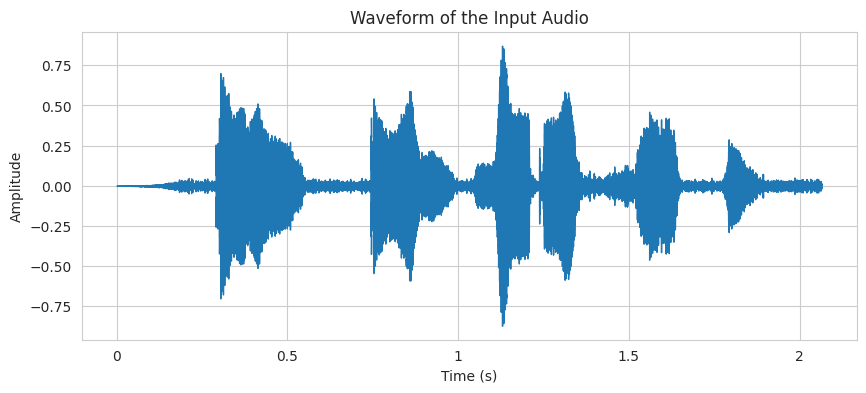

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Transcribed Text: I am very happy


Device set to use cpu


Predicted Sentiment: POSITIVE (Confidence: 1.00)


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
import speech_recognition as sr
from IPython.display import Audio
from transformers import pipeline

# Load the audio file
file_path = "/content/drive/MyDrive/audio/WhatsApp Audio 2025-04-16 at 14.09.34.wav"
audio, sample_rate = librosa.load(file_path, sr=None)

# Plot the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sample_rate)
plt.title("Waveform of the Input Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Play the audio
display(Audio(file_path))

# Convert to PCM WAV format
wav_path = "/content/converted_audio.wav"
sf.write(wav_path, audio, sample_rate, subtype='PCM_16')

# Convert speech to text
recognizer = sr.Recognizer()
with sr.AudioFile(wav_path) as source:
    audio_data = recognizer.record(source)

try:
    transcribed_text = recognizer.recognize_google(audio_data)
    print(f"Transcribed Text: {transcribed_text}")
except sr.UnknownValueError:
    transcribed_text = "[Could not understand the audio]"
except sr.RequestError:
    transcribed_text = "[Speech Recognition service error]"

# Use Hugging Face's sentiment analysis pipeline
if not transcribed_text.startswith("["):
    sentiment_analyzer = pipeline("sentiment-analysis")
    sentiment_result = sentiment_analyzer(transcribed_text)[0]
    predicted_sentiment = f"{sentiment_result['label']} (Confidence: {sentiment_result['score']:.2f})"
else:
    predicted_sentiment = "[Sentiment could not be determined]"

print(f"Predicted Sentiment: {predicted_sentiment}")

In [ ]:
SUBMISSION_FILE= 'submission.csv'
df.to_csv(SUBMISSION_FILE, index=False)
print(f"Submission file saved: {SUBMISSION_FILE}")

Submission file saved: submission.csv


In [ ]:
df = pd.read_csv('submission.csv')
print(df)

    Filename     Class
0    346.wav  Negative
1    163.wav   Neutral
2    288.wav  Negative
3    279.wav  Negative
4    244.wav  Negative
..       ...       ...
245  204.wav   Neutral
246   46.wav  Positive
247  318.wav  Negative
248   49.wav  Positive
249  191.wav   Neutral

[250 rows x 2 columns]
